# 🤖 Model Training

## Objective

This notebook automatically trains multiple Machine Learning models and compares their performance.

### Features

- Automatic problem detection
- Classification & Regression support
- Cross Validation
- Training Time Comparison
- Leaderboard Generation
- Best Model Selection
- Model Saving

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

sns.set_style("whitegrid")

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import *

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# ==========================================================
# Optional Libraries
# ==========================================================

try:

    from xgboost import XGBClassifier, XGBRegressor

    xgb_available = True

except:

    xgb_available = False

try:

    from lightgbm import LGBMClassifier, LGBMRegressor

    lgbm_available = True

except:

    lgbm_available = False

try:

    from catboost import CatBoostClassifier, CatBoostRegressor

    cat_available = True

except:

    cat_available = False

print("XGBoost :", xgb_available)
print("LightGBM :", lgbm_available)
print("CatBoost :", cat_available)

XGBoost : True
LightGBM : True
CatBoost : True


In [3]:
# ==========================================================
# Load Engineered Dataset
# ==========================================================

DATA_PATH = "../data/processed/engineered_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

display(df.head())

(36994, 34)


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,churn
0,0.252523,-0.966389,0.712562,0.700230,1.172672,-0.475563,-0.133784,-0.130690,-0.135197,-0.126553,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,-0.110551,-0.460965,-0.330877,1.705519,1.172672,-0.278289,-0.133200,-0.136127,-0.138771,-0.126228,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,0.036146,-0.067858,-0.330877,-1.085387,-0.341489,-0.268692,-0.104552,-0.115572,-0.114066,-0.092763,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,1.011677,2.346943,-0.330877,0.899413,-1.855650,-0.789069,0.149746,0.148655,0.152553,0.127798,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-1.555510,-0.011700,-0.330877,-1.832910,-0.341489,-0.040494,-0.021270,-0.024014,-0.024500,-0.061926,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [4]:
possible_targets = [

    "target",

    "label",

    "class",

    "output",

    "prediction",

    "churn",

    "price",

    "salary"

]

target = None

for col in df.columns:

    if col.lower() in possible_targets:

        target = col

        break

if target is None:

    target = df.columns[-1]

print("Target :", target)

Target : churn


In [5]:
# ==========================================================
# Problem Detection
# ==========================================================

if df[target].nunique() <= 20:

    problem = "classification"

else:

    problem = "regression"

print(problem.upper())

CLASSIFICATION


In [6]:
X = df.drop(columns=[target])

y = df[target]

print(X.shape)

print(y.shape)

(36994, 33)
(36994,)


In [7]:
if problem == "classification":

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42,

        stratify=y

    )

else:

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.2,

        random_state=42

    )

print(X_train.shape)

print(X_test.shape)

(29595, 33)
(7399, 33)


In [8]:
# ==========================================================
# Classification Models
# ==========================================================

classification_models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(probability=True),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Extra Trees": ExtraTreesClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),

    "Gaussian NB": GaussianNB()

}

if xgb_available:

    classification_models["XGBoost"] = XGBClassifier(

        random_state=42,

        eval_metric="logloss"

    )

if lgbm_available:

    classification_models["LightGBM"] = LGBMClassifier(random_state=42)

if cat_available:

    classification_models["CatBoost"] = CatBoostClassifier(

        verbose=0,

        random_state=42

    )

In [9]:
regression_models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(),

    "Lasso": Lasso(),

    "ElasticNet": ElasticNet(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)

}

if xgb_available:

    regression_models["XGBoost"] = XGBRegressor(random_state=42)

if lgbm_available:

    regression_models["LightGBM"] = LGBMRegressor(random_state=42)

if cat_available:

    regression_models["CatBoost"] = CatBoostRegressor(

        verbose=0,

        random_state=42

    )

In [10]:
if problem == "classification":

    models = classification_models

else:

    models = regression_models

print("Models to Train :", len(models))

print(list(models.keys()))

Models to Train : 13
['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'Extra Trees', 'AdaBoost', 'Gradient Boosting', 'Hist Gradient Boosting', 'Gaussian NB', 'XGBoost', 'LightGBM', 'CatBoost']


In [ ]:
# ==========================================================
# Initialize Leaderboard
# ==========================================================

leaderboard = []

print("Leaderboard Initialized ✅")

Leaderboard Initialized ✅


In [12]:
# ==========================================================
# Train All Models
# ==========================================================

leaderboard = []

for model_name, model in models.items():

    print("\n" + "="*60)
    print(f" Training : {model_name}")
    print("="*60)

    try:

        start_time = time.time()

        # --------------------------------------------------
        # Skip SVM for Large Datasets
        # --------------------------------------------------

        if model_name == "SVM" and len(X_train) > 10000:
            print("⏩ Skipping SVM (Large Dataset)")
            continue

        # --------------------------------------------------
        # Faster Training for KNN
        # --------------------------------------------------

        if model_name == "KNN" and len(X_train) > 10000:

            sample_size = min(10000, len(X_train))

            X_small = X_train.sample(sample_size, random_state=42)
            y_small = y_train.loc[X_small.index]

            model.fit(X_small, y_small)

        else:

            model.fit(X_train, y_train)

        training_time = time.time() - start_time

        y_pred = model.predict(X_test)

        # ==================================================
        # Classification
        # ==================================================

        if problem == "classification":

            accuracy = accuracy_score(y_test, y_pred)

            precision = precision_score(
                y_test,
                y_pred,
                zero_division=0
            )

            recall = recall_score(
                y_test,
                y_pred,
                zero_division=0
            )

            f1 = f1_score(
                y_test,
                y_pred,
                zero_division=0
            )

            cv_scores = cross_val_score(

                model,

                X_train,

                y_train,

                cv=2,

                scoring="accuracy",

                n_jobs=-1

            )

            leaderboard.append({

                "Model": model_name,

                "Accuracy": accuracy,

                "Precision": precision,

                "Recall": recall,

                "F1 Score": f1,

                "CV Mean": cv_scores.mean(),

                "CV Std": cv_scores.std(),

                "Training Time": training_time,

                "Model Object": model

            })

        # ==================================================
        # Regression
        # ==================================================

        else:

            rmse = np.sqrt(

                mean_squared_error(y_test, y_pred)

            )

            mae = mean_absolute_error(

                y_test,

                y_pred

            )

            r2 = r2_score(

                y_test,

                y_pred

            )

            cv_scores = cross_val_score(

                model,

                X_train,

                y_train,

                cv=2,

                scoring="r2",

                n_jobs=-1

            )

            leaderboard.append({

                "Model": model_name,

                "RMSE": rmse,

                "MAE": mae,

                "R2 Score": r2,

                "CV Mean": cv_scores.mean(),

                "CV Std": cv_scores.std(),

                "Training Time": training_time,

                "Model Object": model

            })

        print(f" Completed in {training_time:.2f} seconds")

    except Exception as e:

        print(f" {model_name} Failed")
        print(e)


 Training : Logistic Regression


 Completed in 0.55 seconds

 Training : KNN
 Completed in 0.02 seconds

 Training : SVM
⏩ Skipping SVM (Large Dataset)

 Training : Decision Tree
 Completed in 0.97 seconds

 Training : Random Forest
 Completed in 11.00 seconds

 Training : Extra Trees
 Completed in 12.90 seconds

 Training : AdaBoost
 Completed in 4.36 seconds

 Training : Gradient Boosting
 Completed in 21.58 seconds

 Training : Hist Gradient Boosting
 Completed in 2.14 seconds

 Training : Gaussian NB
 Completed in 0.04 seconds

 Training : XGBoost
 Completed in 1.08 seconds

 Training : LightGBM
[LightGBM] [Info] Number of positive: 14798, number of negative: 14797
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008807 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7531
[LightGBM] [Info] Number of data points in the train set: 29595, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500017 -> initsc

In [13]:
# ==========================================================
# Convert Leaderboard to DataFrame
# ==========================================================

leaderboard = pd.DataFrame(leaderboard)

print("Leaderboard Created Successfully")

leaderboard.head()

Leaderboard Created Successfully


,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time,Model Object
0,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299,LogisticRegression(max_iter=1000)
1,KNN,0.676443,0.637282,0.818870,0.716753,0.711573,0.002172,0.017812,KNeighborsClassifier()
2,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475,DecisionTreeClassifier(random_state=42)
3,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892,"(DecisionTreeClassifier(max_features='sqrt', r..."
4,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737,"(ExtraTreeClassifier(random_state=1608637542),..."


In [14]:
# ==========================================================
# Sort Leaderboard
# ==========================================================

if problem == "classification":

    leaderboard = leaderboard.sort_values(

        by="Accuracy",

        ascending=False

    )

else:

    leaderboard = leaderboard.sort_values(

        by="R2 Score",

        ascending=False

    )

leaderboard.reset_index(drop=True, inplace=True)

leaderboard

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time,Model Object
0,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737,"(ExtraTreeClassifier(random_state=1608637542),..."
1,CatBoost,0.901743,0.926766,0.872398,0.898761,0.889204,0.001044,20.822012,"CatBoostClassifier(random_state=42, verbose=0)"
2,XGBoost,0.900257,0.917160,0.879968,0.898179,0.891468,0.001078,1.081359,"XGBClassifier(base_score=None, booster=None, c..."
3,LightGBM,0.890255,0.912311,0.863477,0.887222,0.881399,0.002564,1.161272,LGBMClassifier(random_state=42)
4,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892,"(DecisionTreeClassifier(max_features='sqrt', r..."
5,Hist Gradient Boosting,0.881741,0.900681,0.858070,0.878859,0.877040,0.000300,2.135445,HistGradientBoostingClassifier(random_state=42)
6,Gradient Boosting,0.854710,0.873789,0.829143,0.850881,0.851292,0.000907,21.575911,"([DecisionTreeRegressor(max_depth=3,\n ..."
7,AdaBoost,0.793891,0.813799,0.762098,0.787100,0.802095,0.002068,4.362210,"(DecisionTreeClassifier(max_depth=1, random_st..."
8,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475,DecisionTreeClassifier(random_state=42)
9,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299,LogisticRegression(max_iter=1000)


In [15]:
# ==========================================================
# Display Best Model
# ==========================================================

best_model_name = leaderboard.iloc[0]["Model"]

best_model = leaderboard.iloc[0]["Model Object"]

print("="*60)
print("🏆 BEST MODEL")
print("="*60)

print(best_model_name)

🏆 BEST MODEL
Extra Trees


In [16]:
# ==========================================================
# Leaderboard Styling
# ==========================================================

leaderboard.style.background_gradient(

    cmap="Greens"

)

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time,Model Object
0,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737,ExtraTreesClassifier(random_state=42)
1,CatBoost,0.901743,0.926766,0.872398,0.898761,0.889204,0.001044,20.822012,"CatBoostClassifier(random_state=42, verbose=0)"
2,XGBoost,0.900257,0.917160,0.879968,0.898179,0.891468,0.001078,1.081359,"XGBClassifier(base_score=None, booster=None, callbacks=None, colsample_bylevel=None, colsample_bynode=None, colsample_bytree=None, device=None, early_stopping_rounds=None, enable_categorical=True, eval_metric='logloss', feature_types=None, feature_weights=None, gamma=None, grow_policy=None, importance_type=None, interaction_constraints=None, learning_rate=None, max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None, max_depth=None, max_leaves=None, min_child_weight=None, missing=nan, monotone_constraints=None, multi_strategy=None, n_estimators=None, n_jobs=None, num_parallel_tree=None, ...)"
3,LightGBM,0.890255,0.912311,0.863477,0.887222,0.881399,0.002564,1.161272,LGBMClassifier(random_state=42)
4,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892,RandomForestClassifier(random_state=42)
5,Hist Gradient Boosting,0.881741,0.900681,0.858070,0.878859,0.877040,0.000300,2.135445,HistGradientBoostingClassifier(random_state=42)
6,Gradient Boosting,0.854710,0.873789,0.829143,0.850881,0.851292,0.000907,21.575911,GradientBoostingClassifier(random_state=42)
7,AdaBoost,0.793891,0.813799,0.762098,0.787100,0.802095,0.002068,4.362210,AdaBoostClassifier(random_state=42)
8,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475,DecisionTreeClassifier(random_state=42)
9,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299,LogisticRegression(max_iter=1000)


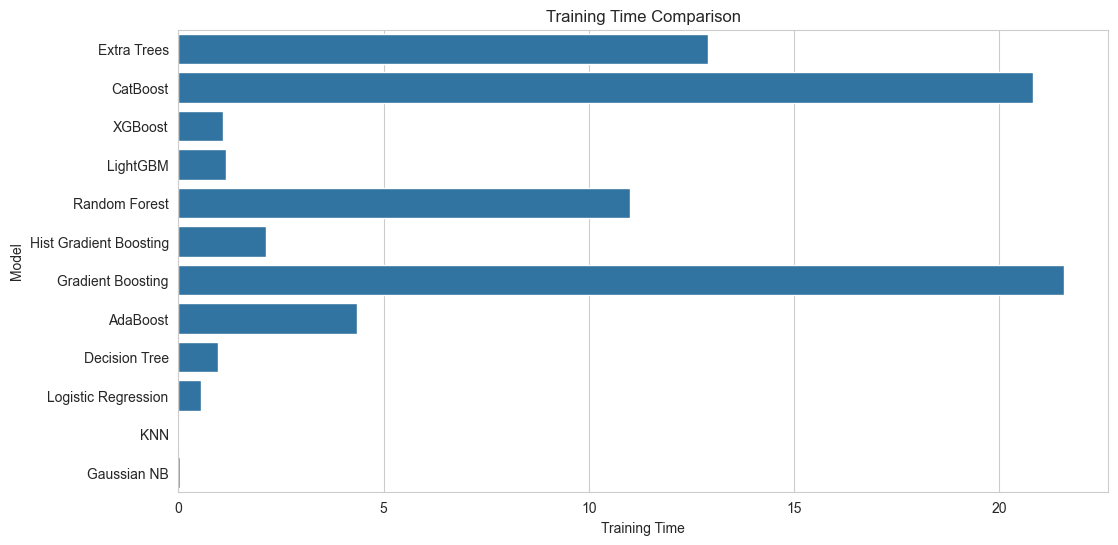

In [17]:
# ==========================================================
# Training Time Comparison
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=leaderboard,

    x="Training Time",

    y="Model",

)

plt.title("Training Time Comparison")

plt.show()

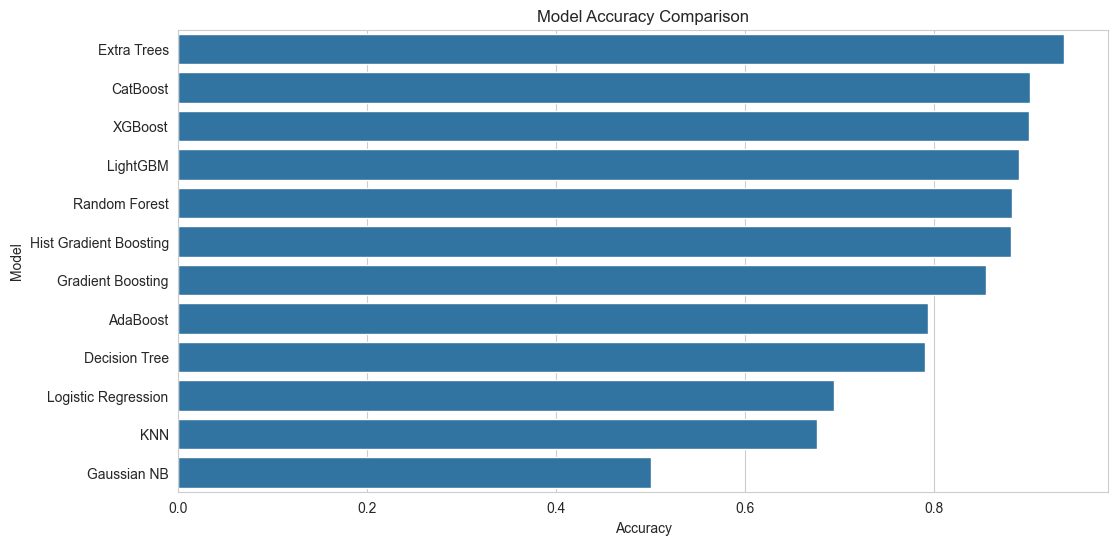

In [18]:
if problem=="classification":

    plt.figure(figsize=(12,6))

    sns.barplot(

        data=leaderboard,

        x="Accuracy",

        y="Model"

    )

    plt.title("Model Accuracy Comparison")

    plt.show()

In [19]:
if problem=="regression":

    plt.figure(figsize=(12,6))

    sns.barplot(

        data=leaderboard,

        x="R2 Score",

        y="Model"

    )

    plt.title("Model R² Comparison")

    plt.show()

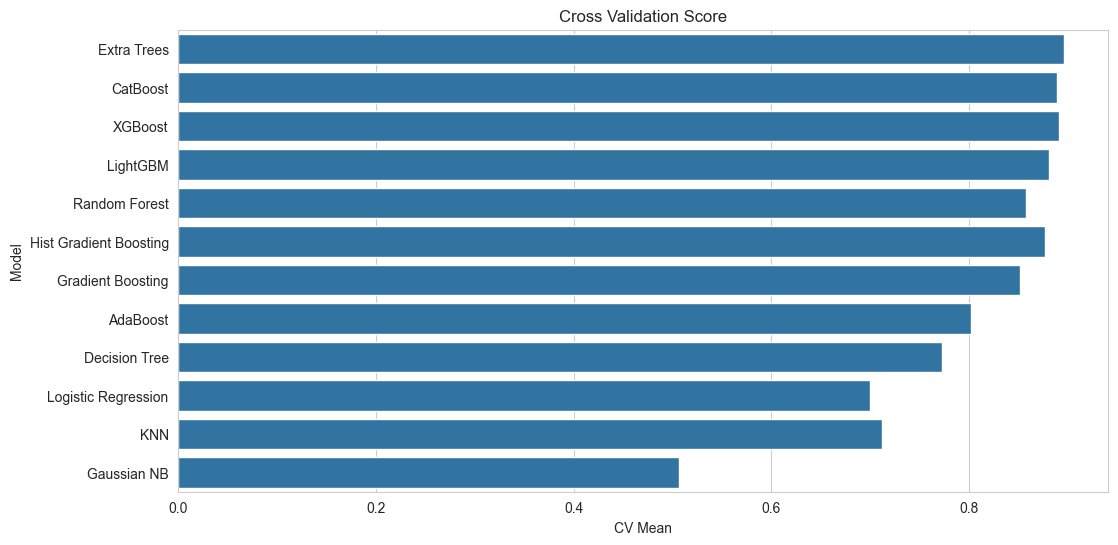

In [20]:
# ==========================================================
# Cross Validation Comparison
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=leaderboard,

    x="CV Mean",

    y="Model"

)

plt.title("Cross Validation Score")

plt.show()

In [21]:
# ==========================================================
# Display Complete Leaderboard
# ==========================================================

pd.set_option("display.max_columns", None)

display(

    leaderboard.drop(columns=["Model Object"])

)

,Model,Accuracy,Precision,Recall,F1 Score,CV Mean,CV Std,Training Time
0,Extra Trees,0.937965,0.947020,0.927818,0.937321,0.896232,0.000443,12.898737
1,CatBoost,0.901743,0.926766,0.872398,0.898761,0.889204,0.001044,20.822012
2,XGBoost,0.900257,0.917160,0.879968,0.898179,0.891468,0.001078,1.081359
3,LightGBM,0.890255,0.912311,0.863477,0.887222,0.881399,0.002564,1.161272
4,Random Forest,0.883227,0.881767,0.885104,0.883432,0.857239,0.002124,10.995892
5,Hist Gradient Boosting,0.881741,0.900681,0.858070,0.878859,0.877040,0.000300,2.135445
6,Gradient Boosting,0.854710,0.873789,0.829143,0.850881,0.851292,0.000907,21.575911
7,AdaBoost,0.793891,0.813799,0.762098,0.787100,0.802095,0.002068,4.362210
8,Decision Tree,0.791053,0.788993,0.794539,0.791756,0.772664,0.003304,0.973475
9,Logistic Regression,0.693878,0.709772,0.655853,0.681748,0.699679,0.008795,0.546299


In [22]:
# ==========================================================
# Save Leaderboard
# ==========================================================

Path("../artifacts").mkdir(exist_ok=True)

leaderboard.drop(

    columns=["Model Object"]

).to_csv(

    "../artifacts/model_leaderboard.csv",

    index=False

)

print("Leaderboard Saved ✅")

Leaderboard Saved ✅


In [30]:
# ==========================================================
# Save Best Model
# ==========================================================

joblib.dump(

    best_model,

    "../artifacts/best_model.pkl"

)

print("Best Model Saved Successfully ✅")

Best Model Saved Successfully ✅


In [24]:
# ==========================================================
# Summary
# ==========================================================

print("="*60)
print("MODEL TRAINING COMPLETED")
print("="*60)

print(f"Problem Type : {problem}")
print(f"Models Trained : {len(models)}")
print(f"Best Model : {best_model_name}")

if problem=="classification":

    print(f"Best Accuracy : {leaderboard.iloc[0]['Accuracy']:.4f}")

else:

    print(f"Best R² : {leaderboard.iloc[0]['R2 Score']:.4f}")

print("="*60)

MODEL TRAINING COMPLETED
Problem Type : classification
Models Trained : 13
Best Model : Extra Trees
Best Accuracy : 0.9380


In [29]:
# ==========================================================
# Save Feature Names
# ==========================================================

joblib.dump(

    list(X.columns),

    "../models/feature_names.pkl"

)

print("✅ Feature Names Saved")

✅ Feature Names Saved


In [28]:
# ==========================================================
# Save Target Column
# ==========================================================

joblib.dump(

    target,

    "../models/target_column.pkl"

)

print("✅ Target Column Saved")

✅ Target Column Saved


,Feature,Importance
12,12,0.080811
6,6,0.073626
13,13,0.061280
17,17,0.050349
14,14,0.046225
18,18,0.044738
1,1,0.042643
3,3,0.042519
5,5,0.041121
15,15,0.039855


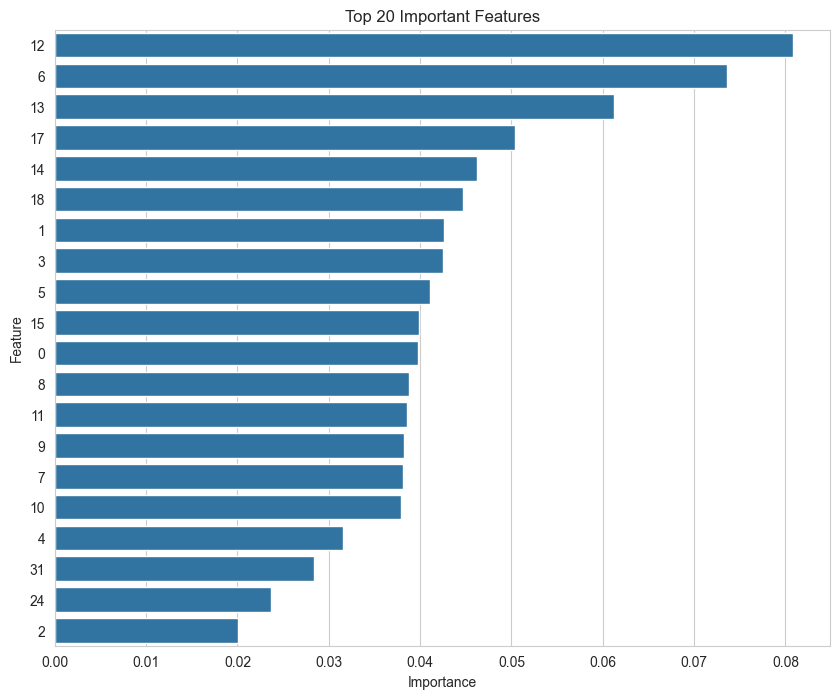

In [27]:
# ==========================================================
# Feature Importance
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    display(

        importance.head(20)

    )

    plt.figure(figsize=(10,8))

    sns.barplot(

        data=importance.head(20),

        y="Feature",

        x="Importance"

    )

    plt.title("Top 20 Important Features")

    plt.show()

else:

    print("Feature Importance Not Available")

In [26]:
# ==========================================================
# Training Summary
# ==========================================================

print("="*60)

print("MODEL TRAINING COMPLETED")

print("="*60)

print(f"Problem Type        : {problem}")

print(f"Total Models        : {len(models)}")

print(f"Best Model          : {best_model_name}")

print(f"Training Samples    : {len(X_train):,}")

print(f"Testing Samples     : {len(X_test):,}")

print(f"Features Used       : {X.shape[1]}")

print("="*60)

MODEL TRAINING COMPLETED
Problem Type        : classification
Total Models        : 13
Best Model          : Extra Trees
Training Samples    : 29,595
Testing Samples     : 7,399
Features Used       : 33


In [25]:
# ==========================================================
# Save Metadata
# ==========================================================

metadata = {

    "Problem Type": problem,

    "Target Column": target,

    "Best Model": best_model_name,

    "Training Samples": len(X_train),

    "Testing Samples": len(X_test),

    "Features": X.shape[1]

}

joblib.dump(

    metadata,

    "../models/model_metadata.pkl"

)

print("✅ Metadata Saved")

✅ Metadata Saved
